# Spatial Statistics of the PDAC Tumour Microenvironment
## Experiment 2 — Sample 34434_1

This notebook applies SpatioEv's spatial statistics toolkit to characterise the spatial organisation
of a pancreatic ductal adenocarcinoma (PDAC) tissue section. The sample features:

- **Invasive tumour ducts** infiltrating into the adjacent duodenum (left/centre of image)
- **Dense desmoplastic stroma** — reactive fibroblasts surrounding tumour nests
- **Residual normal pancreas** on the right, providing an internal spatial reference
- **Heterogeneous immune infiltrate** — T cells, B lineage, macrophages at the tumour margin

The spatial analysis proceeds from global to local:
1. **Self-clustering (Ripley's K)** — how does each cell type organise itself across the tissue?
2. **Pairwise co-localisation (Cross-Ripley K)** — which cell types co-occur and at what scales?
3. **Feature autocorrelation (Moran's I)** — are activated fibroblast states regionally concentrated?
4. **Cross-type feature coupling (Cross-Moran's I)** — is fibroblast activation spatially linked to tumour behaviour?

**Key biological questions:**
- Do B-lineage cells form compact tertiary lymphoid structures, or diffuse infiltrates?
- Is the desmoplastic stroma physically separated from tumour ducts at short range, or interdigitated?
- Are high-FAP (activated CAF) fibroblasts regionally concentrated, or evenly distributed?
- Is fibroblast activation (FAP, aSMA) spatially correlated with ductal cell proliferation (Ki67) and morphological complexity (entropy)?

## Which method for which question?

| Question | Method | Function |
|---|---|---|
| Do cells of type X cluster among themselves? | Ripley's K | `sv.tl.ripleys_k_by_phenotype` |
| At what spatial scale does clustering occur? | Ripley's K curve | `sv.tl.cross_ripleys_curve_by_phenotype` |
| Which individual cells are in local hotspots? | Local Ripley | `sv.tl.ripley_local_counts_by_phenotype` |
| Do types X and Y co-localise? | Cross-Ripley K | `sv.tl.cross_ripleys_k_by_phenotype` |
| Is X–Y co-localisation significant vs random? | Permutation envelope | `sv.tl.cross_ripley_permutation_envelope` |
| Which X cells sit unusually close to Y cells? | Local cross-Ripley | `sv.tl.cross_ripley_local_counts` |
| All pairwise co-localisation simultaneously | Cross-Ripley all pairs | `sv.tl.cross_ripleys_k_all_pairs` |
| Is a continuous feature (e.g. FAP) spatially patchy? | Moran's I | `sv.tl.morans_i_by_image` |
| Where are local hotspots of that feature? | Local Moran's I | `sv.tl.add_local_morans_i` |
| Does feature A in type X co-vary with feature B in nearby type Y? | Cross-Moran's I | `sv.tl.cross_morans_i_feature_matrix` |
| Where locally does that cross-feature coupling occur? | Local cross-Moran's I | `sv.tl.add_local_cross_morans_i_between_phenotypes` |

**Parameter guidance:**
- `radius`: choose in biological units (µm), then divide by pixel size (0.325 µm/px).
  - 20 µm ≈ direct cell-cell contact / immediate neighbours
  - 50 µm ≈ local microenvironment / 2–4 cell diameters
  - 100–200 µm ≈ tissue compartment / regional neighbourhood
- `k` (for Moran's I): number of nearest neighbours for the spatial weight matrix. k=8 balances sensitivity and stability; increase for sparse cell types.

In [1]:
%matplotlib inline
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import mannwhitneyu

import spatioev as sv
import scanpy as sc
from spatioev.config import ClusteringConfig

In [2]:
os.chdir('/Users/shihongwu/SpatioEv')

ADATA_PATH      = "data/exp_2/34434_1_adata.h5ad"
ANNOTATION_PATH = "data/exp_2/34434_1_annotation.csv"
PIXEL_PATH      = "data/exp_2/pixel_features.csv"
PIXEL_SIZE_UM   = 0.325   # µm per pixel

In [3]:
try:
    adata = sv.load_h5ad(ADATA_PATH)
    ann = pd.read_csv(ANNOTATION_PATH, index_col=0)
    ann = ann[[c for c in ["Tier_A", "Tier_B"] if c in ann.columns]]
    adata.obs = adata.obs.join(ann, how="left")
    print(f"Loaded {adata.n_obs} cells from {ADATA_PATH}")
except (FileNotFoundError, OSError):
    print("Real data not found — generating spatially-structured synthetic data.")
    import anndata as ad
    rng = np.random.default_rng(42)

    phenotypes = [
        "pancreatic ductal epithelium", "Fibroblasts", "T cells",
        "B lineage", "Macrophages", "Endothelial cells",
    ]
    markers = [
        "FAP", "aSMA", "PDPN", "Thy1", "Vimentin",
        "CK19", "NaKATPase", "Ki67", "CD31",
        "CD3", "CD4_2", "CD8_2", "FOXP3_2", "GranzymeB",
        "CD19", "CD20",
    ]

    # Generate spatially clustered cells — each phenotype has regional centres
    pheno_centres = {
        "pancreatic ductal epithelium": [(800, 800), (1200, 600), (600, 1400)],
        "Fibroblasts":                  [(900, 900), (1100, 700), (700, 1300)],
        "T cells":                      [(400, 600), (1500, 1000)],
        "B lineage":                    [(350, 550), (360, 560)],
        "Macrophages":                  [(700, 500), (1000, 1200)],
        "Endothelial cells":            [(500, 800), (1300, 900)],
    }
    pheno_counts = {
        "pancreatic ductal epithelium": 360, "Fibroblasts": 300,
        "T cells": 200, "B lineage": 100, "Macrophages": 140, "Endothelial cells": 100,
    }
    n_cells = sum(pheno_counts.values())

    rows = []
    for ph, n in pheno_counts.items():
        centres = pheno_centres[ph]
        for i in range(n):
            cx, cy = centres[i % len(centres)]
            spread = 60 if ph == "B lineage" else 200
            rows.append({
                "X_centroid": cx + rng.normal(0, spread),
                "Y_centroid": cy + rng.normal(0, spread),
                "Tier_A": ph,
                "Tier_B": ph,
                "imageid": rng.choice(["img1", "img2"], p=[0.6, 0.4]),
                "fov": rng.choice(["fov1", "fov2", "fov3"]),
                "label": i,
            })

    obs = pd.DataFrame(rows)
    obs["area"]                    = rng.gamma(4, 50, n_cells)
    obs["nc_ratio"]                = rng.beta(2, 5, n_cells)
    obs["eccentricity"]            = rng.uniform(0.1, 0.9, n_cells)
    obs["major_axis_length"]       = rng.gamma(3, 10, n_cells)
    obs["minor_axis_length"]       = rng.gamma(2, 6, n_cells)
    obs["perimeter"]               = rng.gamma(4, 15, n_cells)
    obs["convex_area"]             = obs["area"] * rng.uniform(1.0, 1.2, n_cells)
    obs["equivalent_diameter"]     = rng.gamma(3, 8, n_cells)
    obs["solidity"]                = rng.beta(8, 2, n_cells)
    obs["feret_diameter_max"]      = rng.gamma(4, 12, n_cells)
    obs["major_minor_axis_ratio"]  = rng.gamma(2, 1, n_cells) + 1
    obs["perim_square_over_area"]  = rng.gamma(3, 5, n_cells)
    obs["major_axis_equiv_diam_ratio"] = rng.gamma(2, 1, n_cells)
    obs["convex_hull_resid"]       = rng.beta(1, 5, n_cells)
    obs["centroid_dif"]            = rng.gamma(1, 2, n_cells)
    obs["num_concavities"]         = rng.poisson(3, n_cells).astype(float)
    obs["circularity"]             = rng.beta(4, 2, n_cells)
    obs["fractal_dimension"]       = rng.uniform(1.0, 2.0, n_cells)
    obs["boundary_irregularity"]   = rng.gamma(2, 0.1, n_cells)
    obs["polarity_score"]          = rng.uniform(0, 1, n_cells)
    obs["entropy"]                 = rng.uniform(0, 3, n_cells)
    obs["inertia"]                 = rng.gamma(2, 1, n_cells)

    X = rng.exponential(1, (n_cells, len(markers))).astype("float32")
    adata = ad.AnnData(X=X, obs=obs, var=pd.DataFrame(index=markers))
    adata.obs.index = [f"cell_{i}" for i in range(n_cells)]
    print(f"Synthetic dataset: {adata.n_obs} cells, {adata.n_vars} markers")

Loaded 1766481 cells from data/exp_2/34434_1_adata.h5ad


In [4]:
try:
    pix = pd.read_csv(PIXEL_PATH, index_col=0)
    adata.obs = adata.obs.merge(pix, on=["label", "fov"], how="left")
    pix_cols  = pix.columns.tolist()
    mask      = adata.obs[pix_cols].notna().all(axis=1)
    print(f"Pixel features joined: keeping {mask.sum()} / {len(mask)} cells")
    adata     = adata[mask].copy()
except (FileNotFoundError, OSError, KeyError):
    print("Pixel features not found — polarity_score / entropy / inertia from synthetic obs.")

Pixel features joined: keeping 1763634 / 1766481 cells


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


---
## 1  Self-clustering: how does each cell type distribute itself?

**Biological rationale:** In PDAC, different cell populations occupy distinct spatial niches:
- Tumour ducts form compact invasive glands — strong short-range clustering expected
- Desmoplastic fibroblasts fill the stroma between glands — regional, diffuse clustering
- B lineage cells may condense into tertiary lymphoid structures — tight, focal clustering
- T cells often infiltrate diffusely or form a loose peri-tumoural rim

Ripley's K (specifically L(r) − r) quantifies whether cells are more clustered (+),
more dispersed (−), or randomly distributed (~0) relative to complete spatial randomness,
at radius r. Running it across multiple radii reveals the *scale* of organisation.

In [5]:
# 50 µm = local microenvironment (~2–4 cell diameters)
radius_50um = 50 / PIXEL_SIZE_UM

ripley_df = sv.tl.ripleys_k_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    radius=radius_50um,
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
)
ripley_df.sort_values("L_minus_r", ascending=False)

,imageid,phenotype,radius,K_observed,K_expected,L,L_minus_r
11,34434_1,Muscularis mucosa,153.846154,2.219998e+07,74357.22257,2658.284045,2504.437891
12,34434_1,Islets,153.846154,1.087030e+07,74357.22257,1860.140659,1706.294505
10,34434_1,Nerves,153.846154,8.209721e+06,74357.22257,1616.550406,1462.704252
13,34434_1,Duodenum epithelial,153.846154,7.639952e+06,74357.22257,1559.446145,1405.599991
6,34434_1,noise,153.846154,6.494108e+06,74357.22257,1437.754785,1283.908631
14,34434_1,Necrotic tumor,153.846154,4.294818e+06,74357.22257,1169.223220,1015.377067
15,34434_1,Unknown,153.846154,2.132806e+06,74357.22257,823.949853,670.103699
2,34434_1,Vascular smooth muscle,153.846154,2.106289e+06,74357.22257,818.811750,664.965596
7,34434_1,B lineage,153.846154,1.321619e+06,74357.22257,648.601939,494.755785
8,34434_1,Muscularis externa,153.846154,8.236168e+05,74357.22257,512.020859,358.174705


**Output columns:**
- `phenotype` — cell type
- `imageid` — which image/FOV
- `n_cells` — number of cells of this type
- `K` — raw Ripley K statistic
- `L_minus_r` — the centred L-statistic: **positive = clustered, negative = dispersed, ~0 = random**

At 50 µm, we expect ductal epithelium and fibroblasts to be strongly positive (gland and
stroma nesting), while endothelial cells may be less clustered (vessels thread through all compartments).

In [6]:
radii_um = [20, 50, 100, 150, 200]
radii_px = [r / PIXEL_SIZE_UM for r in radii_um]

ripley_all = pd.concat([
    sv.tl.ripleys_k_by_phenotype(
        adata, phenotype_key="Tier_A", radius=r,
        x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    )
    for r in radii_px
], ignore_index=True)

# Replace raw pixel radii with readable µm labels
radius_map = dict(zip(radii_px, [f"{r} µm" for r in radii_um]))
ripley_all["radius_label"] = ripley_all["radius"].map(radius_map)

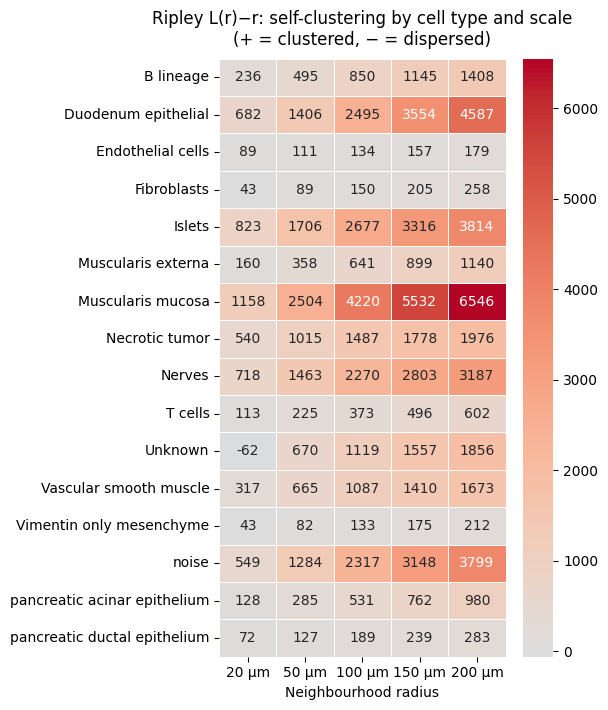

In [7]:
heat_df = (
    ripley_all
    .groupby(["phenotype", "radius_label"], observed=False)["L_minus_r"]
    .mean()
    .unstack()
    .reindex(columns=[f"{r} µm" for r in radii_um])
)

fig, ax = plt.subplots(figsize=(6, max(3, 0.45 * heat_df.shape[0])))
sns.heatmap(
    heat_df, cmap="coolwarm", center=0, linewidths=0.5,
    annot=True, fmt=".0f", ax=ax,
)
ax.set_title("Ripley L(r)−r: self-clustering by cell type and scale\n(+ = clustered, − = dispersed)", pad=10)
ax.set_xlabel("Neighbourhood radius")
ax.set_ylabel("")
fig.tight_layout()

**Reading the heatmap in PDAC context:**

| Pattern | Interpretation |
|---|---|
| Ductal epithelium strongly + at all scales | Tumour forms compact invasive glands and larger regional nests |
| Fibroblasts + at 50–200 µm but weaker at 20 µm | Desmoplastic stroma fills compartments but individual fibroblasts aren't in immediate contact |
| B lineage strongly + at 20–50 µm only | Consistent with tight TLS aggregates (follicle-like structures) |
| T cells weakly + or ~ 0 | Diffuse peri-tumoural infiltration rather than organised clusters |
| Macrophages + at intermediate scales | Regional TAM (tumour-associated macrophage) aggregation |

If normal pancreas is on the right of this section, ductal epithelium may show two modes of clustering:
tight invasive glands (left) and more regular acinar-like spacing (right).

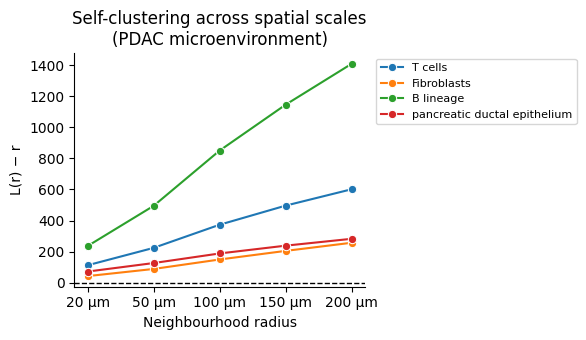

In [8]:
selected = ["pancreatic ductal epithelium", "Fibroblasts", "T cells", "B lineage"]
plot_df = ripley_all[ripley_all["phenotype"].isin(selected)].copy()

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.lineplot(
    data=plot_df, x="radius_label", y="L_minus_r",
    hue="phenotype", marker="o", ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Neighbourhood radius")
ax.set_ylabel("L(r) − r")
ax.set_title("Self-clustering across spatial scales\n(PDAC microenvironment)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
sns.despine()
fig.tight_layout()

In [9]:
# Identify per-cell local clustering at 50 µm
# add_to_obs=True writes hotspot/excess columns directly into adata.obs
local_df = sv.tl.ripley_local_counts_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    radius=radius_50um,
    x_key="X_centroid",
    y_key="Y_centroid",
    image_key="imageid",
    add_to_obs=True,
)

# Dynamically find the column names
hotspot_col = [c for c in adata.obs.columns if "ripley_local_hotspot" in c][0]
excess_col  = [c for c in adata.obs.columns if "ripley_local_excess" in c][0]
print(f"Hotspot column: {hotspot_col}")
print(f"Excess column:  {excess_col}")

Hotspot column: ripley_local_hotspot__Tier_A__r153.84615384615384
Excess column:  ripley_local_excess__Tier_A__r153.84615384615384


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_40382/2182830242.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


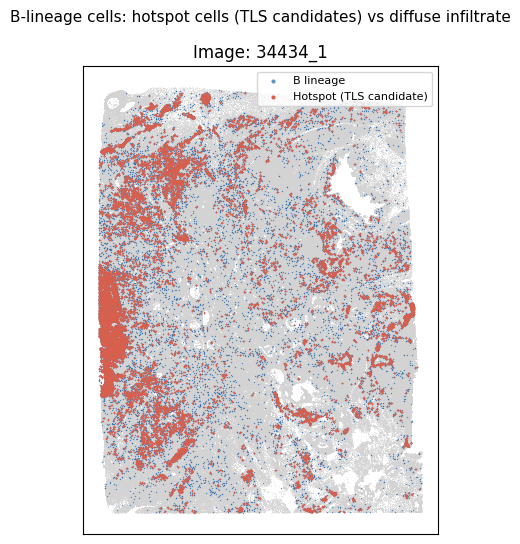

In [11]:
b_mask   = adata.obs["Tier_A"] == "B lineage"
hot_mask = b_mask & adata.obs[hotspot_col].fillna(False)

images = adata.obs["imageid"].unique()
n_img  = len(images)
fig, axes = plt.subplots(1, n_img, figsize=(6.5 * n_img, 5.5))
if n_img == 1:
    axes = [axes]

for ax, image_id in zip(axes, images):
    sub_df  = adata.obs[adata.obs["imageid"] == image_id]
    b_sub   = sub_df[sub_df["Tier_A"] == "B lineage"]
    hot_sub = b_sub[adata.obs.loc[b_sub.index, hotspot_col].fillna(False)]

    ax.scatter(sub_df["X_centroid"], sub_df["Y_centroid"],
               c="lightgray", s=0.5, alpha=0.25, linewidths=0, rasterized=True)
    ax.scatter(b_sub["X_centroid"], b_sub["Y_centroid"],
               c="#2166ac", s=1, alpha=0.7, linewidths=0, label="B lineage")
    ax.scatter(hot_sub["X_centroid"], hot_sub["Y_centroid"],
               c="#d6604d", s=1, linewidths=0, label="Hotspot (TLS candidate)")

    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Image: {image_id}")
    ax.legend(fontsize=8, markerscale=3)

fig.suptitle("B-lineage cells: hotspot cells (TLS candidates) vs diffuse infiltrate", fontsize=11)
fig.tight_layout()

---
## 2  Pairwise co-localisation: which cell types co-occur?

**Biological rationale:** PDAC is characterised by a dense desmoplastic reaction —
reactive fibroblasts accumulate *around* tumour ducts. However, at the very shortest range
(< 20 µm, immediate cell contact), the epithelium and stroma are physically separated by
a basement membrane. This means we expect:
- **Fibroblasts strongly co-enriched with ductal epithelium at 50–200 µm** (peritumoral stroma)
- **A gap (negative L) at 20 µm** (direct epithelium-fibroblast contact is limited)
- **T cells ambiguous**: either excluded from tumour core (immune desert phenotype) or infiltrating

Cross-Ripley K L(r) − r > 0 means source cells have *more* target neighbours within radius r
than expected under random mixing of the two types.

In [12]:
# At 20 µm: test for direct contact zone
cr_20 = sv.tl.cross_ripleys_k_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="Fibroblasts",
    radius=20 / PIXEL_SIZE_UM,
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
)
print("Cross-Ripley at 20 µm (ductal epithelium → Fibroblasts):")
print(cr_20.to_string(index=False))

Cross-Ripley at 20 µm (ductal epithelium → Fibroblasts):
imageid                       source      target    radius  K_observed   K_expected         L  L_minus_r  mean_target_neighbors_per_source  expected_target_neighbors_per_source  source_neighbor_excess  source_neighbor_ratio  fraction_source_with_target_neighbor  directional_observed  directional_expected  directional_excess  directional_ratio
34434_1 pancreatic ductal epithelium Fibroblasts 61.538462 6143.817791 11897.155611 44.222595 -17.315866                          1.010973                              1.957692               -0.946719               0.516411                              0.398053              1.010973              1.957692           -0.946719           0.516411


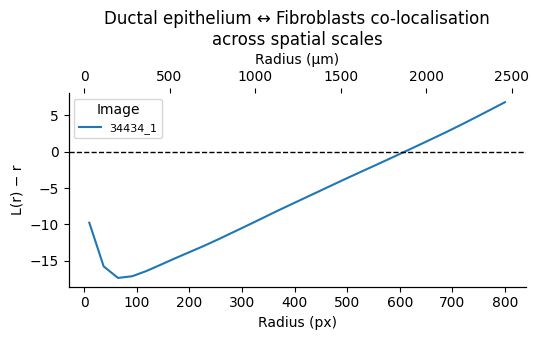

In [13]:
radii_curve = np.linspace(10, 800, 30)

curve = sv.tl.cross_ripleys_curve_by_phenotype(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="Fibroblasts",
    radii=radii_curve,
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
sns.lineplot(data=curve, x="radius", y="L_minus_r", hue="imageid", ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Radius (px)")
ax.set_ylabel("L(r) − r")
ax.set_title("Ductal epithelium ↔ Fibroblasts co-localisation\nacross spatial scales")
ax.legend(title="Image", fontsize=8)
# Add µm reference ticks on top axis
ax2 = ax.twiny()
ax2.set_xlim([r / PIXEL_SIZE_UM for r in ax.get_xlim()])
ax2.set_xlabel("Radius (µm)")
sns.despine()
fig.tight_layout()

**Interpreting the ductal–fibroblast co-localisation curve:**

- If L(r)−r is **negative at 20 µm then positive at 50–200 µm**: classic desmoplastic PDAC pattern —
  fibroblasts surround but don't intermingle with tumour ducts. The basement membrane creates a
  short-range exclusion zone, then the peri-ductal stroma begins.
- If L(r)−r is **positive at all radii**: fibroblasts are uniformly interspersed with tumour cells
  (more invasive, less-organised stroma).
- **Variation across images**: different FOVs may capture different tumour regions —
  compare the left (invasive front) vs right (normal pancreas) if imageid distinguishes them.

In [14]:
cross_local_df = sv.tl.cross_ripley_local_counts(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="Fibroblasts",
    radius=50 / PIXEL_SIZE_UM,
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    add_to_obs=True,
)

# Discover column names for this specific pair
_prefix = "cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__"
_pair_cols = {
    k: v for k, v in {
        "hotspot": next((c for c in adata.obs.columns if c.startswith(_prefix) and c.endswith("__hotspot")), None),
        "count":   next((c for c in adata.obs.columns if c.startswith(_prefix) and c.endswith("__count")),   None),
        "excess":  next((c for c in adata.obs.columns if c.startswith(_prefix) and c.endswith("__excess")),  None),
        "ratio":   next((c for c in adata.obs.columns if c.startswith(_prefix) and c.endswith("__ratio")),   None),
    }.items() if v is not None
}
print("Pair columns found:")
for k, v in _pair_cols.items():
    print(f"  {k}: {v}")

Pair columns found:
  hotspot: cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__r153.84615384615384__hotspot
  count: cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__r153.84615384615384__count
  excess: cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__r153.84615384615384__excess
  ratio: cross_ripley_local__pancreatic ductal epithelium__to__Fibroblasts__r153.84615384615384__ratio


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_40382/1376187442.py:61: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


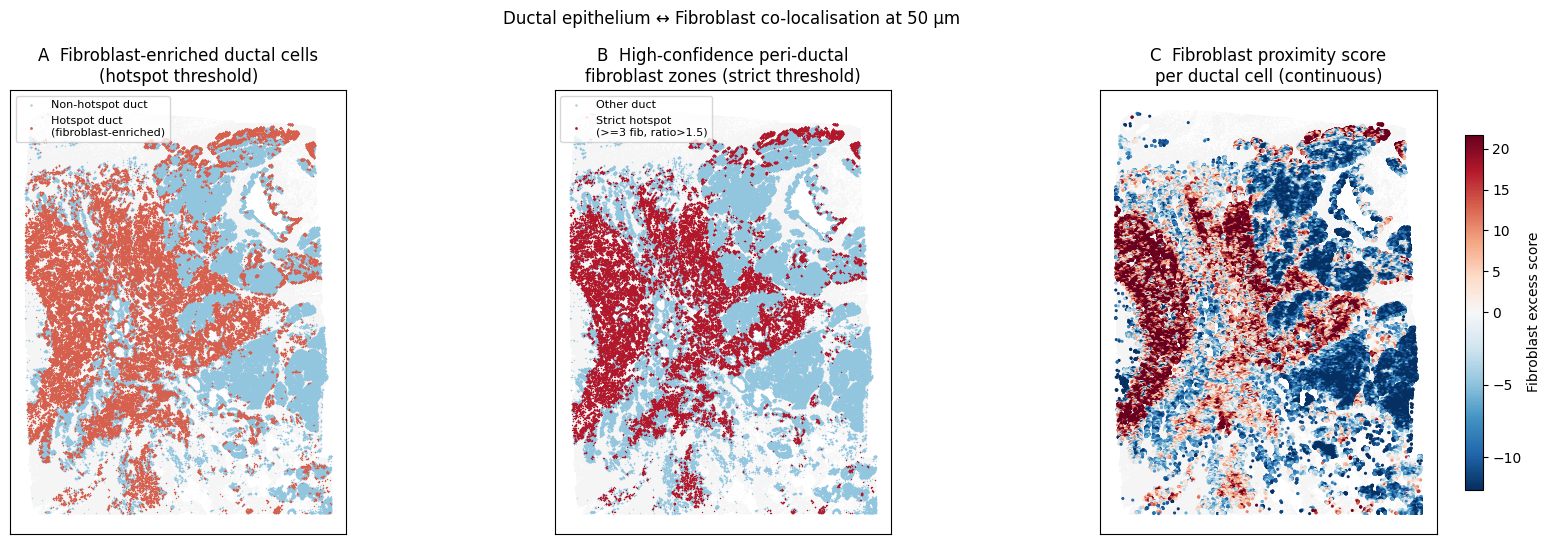

In [17]:
duct_mask = adata.obs["Tier_A"] == "pancreatic ductal epithelium"

# Hotspot = above-median fibroblast neighbour count
hot_mask = duct_mask & adata.obs[_pair_cols["hotspot"]].fillna(False)

# Strict hotspot = >=3 fibroblast neighbours AND ratio > 1.5
strict_mask = (
    duct_mask &
    (adata.obs[_pair_cols["count"]].fillna(0) >= 3) &
    (adata.obs[_pair_cols["ratio"]].fillna(0) > 1.5)
)

excess_vals = adata.obs.loc[duct_mask, _pair_cols["excess"]]
norm = mcolors.TwoSlopeNorm(
    vmin=excess_vals.quantile(0.05), vcenter=0, vmax=excess_vals.quantile(0.95)
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Panel A: hotspot vs non-hotspot
ax = axes[0]
ax.scatter(adata.obs["X_centroid"], adata.obs["Y_centroid"],
           c="whitesmoke", s=0.4, alpha=0.2, linewidths=0, rasterized=True)
ax.scatter(adata.obs.loc[duct_mask & ~hot_mask, "X_centroid"],
           adata.obs.loc[duct_mask & ~hot_mask, "Y_centroid"],
           c="#92c5de", s=1, alpha=0.7, linewidths=0, label="Non-hotspot duct")
ax.scatter(adata.obs.loc[hot_mask, "X_centroid"],
           adata.obs.loc[hot_mask, "Y_centroid"],
           c="#d6604d", s=1, linewidths=0, label="Hotspot duct\n(fibroblast-enriched)")
ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("A  Fibroblast-enriched ductal cells\n(hotspot threshold)")
ax.legend(fontsize=8, markerscale=2)

# Panel B: strict hotspot
ax = axes[1]
ax.scatter(adata.obs["X_centroid"], adata.obs["Y_centroid"],
           c="whitesmoke", s=0.4, alpha=0.2, linewidths=0, rasterized=True)
ax.scatter(adata.obs.loc[duct_mask & ~strict_mask, "X_centroid"],
           adata.obs.loc[duct_mask & ~strict_mask, "Y_centroid"],
           c="#92c5de", s=1, alpha=0.7, linewidths=0, label="Other duct")
ax.scatter(adata.obs.loc[strict_mask, "X_centroid"],
           adata.obs.loc[strict_mask, "Y_centroid"],
           c="#b2182b", s=1, linewidths=0, label="Strict hotspot\n(>=3 fib, ratio>1.5)")
ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("B  High-confidence peri-ductal\nfibroblast zones (strict threshold)")
ax.legend(fontsize=8, markerscale=2)

# Panel C: continuous excess score
ax = axes[2]
ax.scatter(adata.obs.loc[~duct_mask, "X_centroid"],
           adata.obs.loc[~duct_mask, "Y_centroid"],
           c="whitesmoke", s=0.4, alpha=0.15, linewidths=0, rasterized=True)
sc = ax.scatter(adata.obs.loc[duct_mask, "X_centroid"],
                adata.obs.loc[duct_mask, "Y_centroid"],
                c=excess_vals, cmap="RdBu_r", norm=norm, s=5, linewidths=0)
plt.colorbar(sc, ax=ax, label="Fibroblast excess score", shrink=0.8)
ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("C  Fibroblast proximity score\nper ductal cell (continuous)")

fig.suptitle("Ductal epithelium ↔ Fibroblast co-localisation at 50 µm", fontsize=12)
fig.tight_layout()

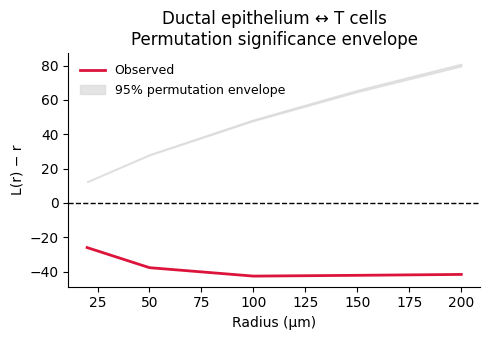

In [16]:
# Permutation envelope for ductal epithelium vs T cells
# Label permutation: shuffles phenotype labels, tests whether the pattern is label-specific
radii_env = np.array([r / PIXEL_SIZE_UM for r in [20, 50, 100, 150, 200]])

perm_df = sv.tl.cross_ripley_permutation_envelope(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="T cells",
    radii=radii_env,
    n_sim=99,        # increase to 499-999 for publication
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    random_state=42,
)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(perm_df["radius"] * PIXEL_SIZE_UM, perm_df["L_minus_r"],
        color="crimson", linewidth=2, label="Observed")
ax.fill_between(
    perm_df["radius"] * PIXEL_SIZE_UM,
    perm_df["envelope_low"], perm_df["envelope_high"],
    color="lightgray", alpha=0.6, label="95% permutation envelope",
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Radius (µm)")
ax.set_ylabel("L(r) − r")
ax.set_title("Ductal epithelium ↔ T cells\nPermutation significance envelope")
ax.legend(frameon=False, fontsize=9)
sns.despine()
fig.tight_layout()

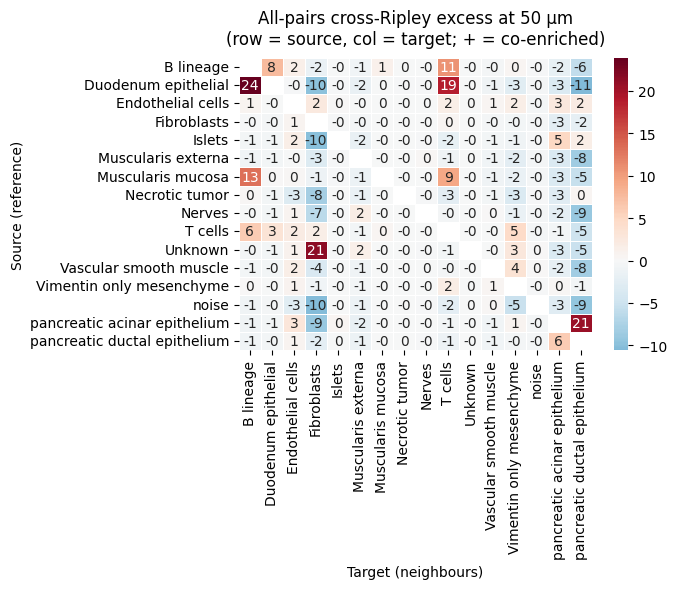

In [18]:
cross_all = sv.tl.cross_ripleys_k_all_pairs(
    adata,
    phenotype_key="Tier_A",
    radius=50 / PIXEL_SIZE_UM,
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    include_self_pairs=False,
)

heat_df = (
    cross_all
    .groupby(["source", "target"], observed=False)["source_neighbor_excess"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    heat_df, cmap="RdBu_r", center=0, linewidths=0.5,
    annot=True, fmt=".0f", ax=ax,
)
ax.set_title("All-pairs cross-Ripley excess at 50 µm\n(row = source, col = target; + = co-enriched)", pad=10)
ax.set_xlabel("Target (neighbours)")
ax.set_ylabel("Source (reference)")
fig.tight_layout()

**Reading the all-pairs heatmap for PDAC:**

- **Ductal epithelium ↔ Fibroblasts** row/column: positive = desmoplastic stroma confirmed;
  magnitude tells you how strong the peri-ductal fibroblast enrichment is
- **T cells → Ductal epithelium** (column): negative = immune exclusion (T cells avoid tumour core);
  positive = immune infiltration
- **B lineage** rows/columns: if B↔B is strongly positive but B↔T is moderate,
  B cells are forming TLS-like structures rather than mixed infiltrates
- **Macrophages**: often co-enriched with both tumour ducts and fibroblasts in PDAC
  (peritumoral TAM accumulation)
- **Directional asymmetry** (row ≠ column transpose): e.g. if fibroblasts have many ductal
  neighbours but ductal cells have few fibroblast neighbours, the stroma encapsulates the
  tumour rather than the tumour infiltrating into stroma

This heatmap provides a single-image snapshot of the spatial wiring diagram of the TME.

---
## 3  Feature autocorrelation: are activated fibroblast states regionally concentrated?

**Biological rationale:** Even within the fibroblast compartment, there is functional heterogeneity.
CAFs (cancer-associated fibroblasts) marked by high FAP, aSMA, and PDPN represent an
activated, pro-tumorigenic state. A key question is: **are high-FAP CAFs spatially concentrated
near tumour ducts, or are they uniformly distributed throughout the stroma?**

Moran's I answers: *do cells with similar FAP expression cluster spatially?*
- I > 0: FAP-high fibroblasts cluster together → regional CAF activation zones exist
- I ~ 0: FAP expression is spatially random → uniform activation throughout stroma
- I < 0: FAP-high and FAP-low fibroblasts alternate (rare in biology)

Spatial CAF concentration near tumour ducts would suggest tumour-to-stroma signalling is
locally instructing fibroblast activation — a key mechanistic question in PDAC biology.

In [19]:
# Copy marker expression from adata.X into adata.obs for spatial statistics
adata = sv.add_obs_from_var(
    adata,
    markers=["FAP", "aSMA", "PDPN", "Thy1"],
    zscore=True,
)

adata_fib = adata[adata.obs["Tier_A"] == "Fibroblasts"].copy()
print(f"Fibroblasts: {adata_fib.n_obs} cells")
print(f"FAP_expr_z range: {adata_fib.obs['FAP_expr_z'].min():.2f} – {adata_fib.obs['FAP_expr_z'].max():.2f}")

Fibroblasts: 447469 cells
FAP_expr_z range: -12.18 – 4.94


In [20]:
# morans_i_by_image: computes per-image Moran's I with KNN spatial weights
fap_moran = sv.tl.morans_i_by_image(
    adata_fib,
    value_key="FAP_expr_z",
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    k=8,   # 8 nearest neighbours — balances sensitivity and stability
)
fap_moran

,imageid,morans_i
0,34434_1,0.81568


In [22]:
fap_moran_perm = sv.tl.morans_i_by_image_permutation_test(
    adata_fib,
    value_key="FAP_expr_z",
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    k=8,
    n_sim=9,   # 999 permutations -> empirical p-value resolution of 0.001
    random_state=42,
)
fap_moran_perm

,imageid,observed,p_value,null_mean,null_std,z_score,n_sim
0,34434_1,0.81568,0.1,0.000082,0.000569,1433.759664,9


**Interpreting FAP Moran's I:**

If I > 0 and p < 0.05: FAP expression is spatially non-random — there are regional zones of
high and low CAF activation. This is consistent with:
- Tumour proximity driving fibroblast activation (peritumoral CAF activation zone)
- Pre-existing stromal heterogeneity in the normal vs tumour pancreatic tissue

Next: **local Moran's I** will map exactly *where* those high-FAP clusters are.

In [23]:
# Add per-cell local Moran score
adata_fib = sv.tl.add_local_morans_i(
    adata_fib,
    value_key="FAP_expr_z",
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    k=8,
)
# Classify each cell into spatial quadrants
adata_fib = sv.tl.add_local_morans_i_quadrants(adata_fib, value_key="FAP_expr_z")

fap_quad_col = "local_morans_quadrant__FAP_expr_z"
print("Quadrant counts:")
print(adata_fib.obs[fap_quad_col].value_counts())

Quadrant counts:
local_morans_quadrant__FAP_expr_z
high-high    316540
low-low       79681
high-low      50305
low-high        943
Name: count, dtype: int64


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_40382/1834604788.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


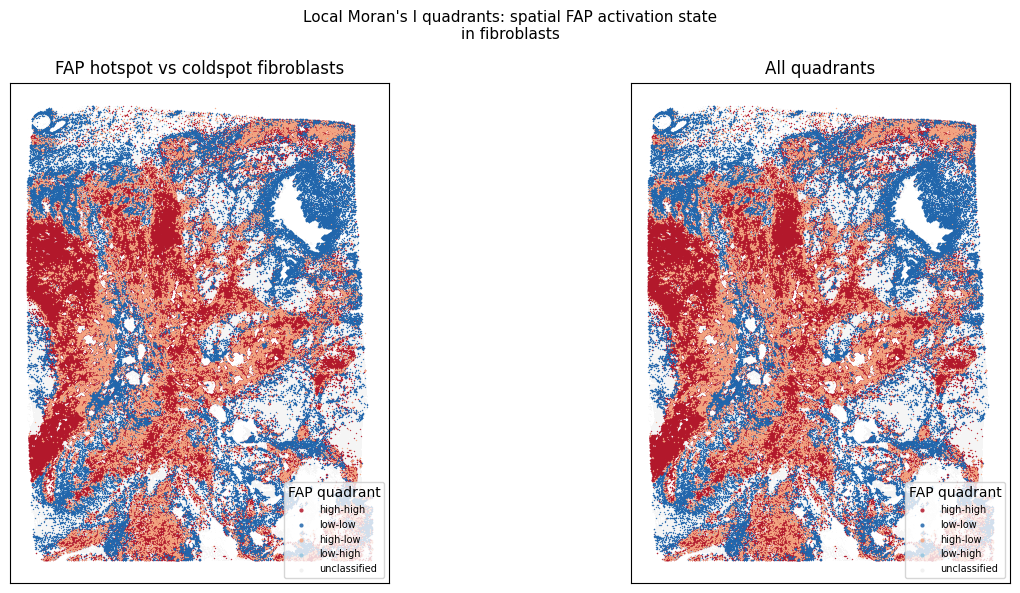

In [25]:
palette = {
    "high-high":    "#b2182b",    # FAP-high surrounded by FAP-high -> core CAF hotspot
    "low-low":      "#2166ac",    # FAP-low surrounded by FAP-low -> quiescent fibroblast zone
    "high-low":     "#f4a582",    # FAP-high isolated -> individual activated cells
    "low-high":     "#92c5de",    # FAP-low surrounded by high -> edge of CAF zone
    "unclassified": "lightgray",
}

quad_map = adata_fib.obs[fap_quad_col].fillna("unclassified")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax in axes:
    # Background: all cells
    ax.scatter(adata.obs["X_centroid"], adata.obs["Y_centroid"],
               c="whitesmoke", s=0.3, alpha=0.15, linewidths=0, rasterized=True)
    # Fibroblasts coloured by quadrant
    for quad, color in palette.items():
        sub = adata_fib.obs[quad_map == quad]
        ax.scatter(sub["X_centroid"], sub["Y_centroid"],
                   c=color, s=1 if quad != "unclassified" else 1,
                   alpha=0.85 if quad != "unclassified" else 0.3,
                   linewidths=0, label=quad, rasterized=True)

    ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, markerscale=3, title="FAP quadrant")

axes[0].set_title("FAP hotspot vs coldspot fibroblasts")
axes[1].set_title("All quadrants")

fig.suptitle("Local Moran's I quadrants: spatial FAP activation state\nin fibroblasts", fontsize=11)
fig.tight_layout()

---
## 4  Cross-type feature coupling: is fibroblast activation linked to tumour behaviour?

**Biological rationale:** If PDAC tumour cells are instructing nearby fibroblasts to activate
(via TGF-β, PDGF, or other paracrine signals), we would expect:
- Fibroblast FAP/aSMA expression to be highest **near actively proliferating or morphologically complex tumour ducts**
- Ductal cell morphological disorganisation (high entropy, irregular shape) to correlate with
  **surrounding high-FAP stroma** — the invasion front
- This spatial coupling would be absent in the normal pancreas region

Cross-Moran's I answers: *for source cells of type A, does their feature value correlate with
the mean feature value of nearby type-B cells?* Positive = co-variation; negative = anticorrelation.

In [29]:
adata = sv.add_obs_from_var(
    adata,
    markers=["FAP", "aSMA", "PDPN", "Thy1", "Ki67", "CK19", "NaKATPase"],
    zscore=True,
    overwrite=True
)

adata = sv.add_zscore_obs_features(
    adata,
    feature_keys=["nc_ratio", "polarity_score", "entropy", "inertia"],
)

print("Feature columns available:")
feat_cols = [c for c in adata.obs.columns if c.endswith("_expr_z") or c.endswith("_z")]
print(feat_cols)

Feature columns available:
['FAP_expr_z', 'aSMA_expr_z', 'PDPN_expr_z', 'Thy1_expr_z', 'Ki67_expr_z', 'CK19_expr_z', 'NaKATPase_expr_z', 'nc_ratio_z', 'polarity_score_z', 'entropy_z', 'inertia_z']


In [30]:
# Core question: are fibroblasts with high FAP preferentially near proliferating (Ki67+) tumour cells?
pair_df = sv.tl.cross_morans_i_feature_matrix(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="Fibroblasts",
    target_phenotype="pancreatic ductal epithelium",
    source_feature_keys=["FAP_expr_z"],
    target_feature_keys=["Ki67_expr_z"],
    radius=50 / PIXEL_SIZE_UM,
    agg="mean",
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    k=8,
)
print(pair_df.to_string(index=False))
print()
print("Interpretation: positive cross_morans_i = FAP-high fibroblasts cluster near Ki67-high ductal cells")
print("-> consistent with proliferating tumour cells driving local CAF activation")

imageid source_phenotype             target_phenotype source_feature target_feature     target_summary_feature  cross_morans_i  n_source_cells  n_nonmissing_pairs
34434_1      Fibroblasts pancreatic ductal epithelium     FAP_expr_z    Ki67_expr_z neighbor_mean__Ki67_expr_z       -0.012759          447469              330366

Interpretation: positive cross_morans_i = FAP-high fibroblasts cluster near Ki67-high ductal cells
-> consistent with proliferating tumour cells driving local CAF activation


In [31]:
fib_features  = ["FAP_expr_z", "aSMA_expr_z", "PDPN_expr_z", "Thy1_expr_z"]
duct_features = ["Ki67_expr_z", "CK19_expr_z", "NaKATPase_expr_z",
                 "nc_ratio_z", "polarity_score_z", "entropy_z", "inertia_z"]

# Filter to features that actually exist in adata.obs
fib_features  = [f for f in fib_features  if f in adata.obs.columns]
duct_features = [f for f in duct_features if f in adata.obs.columns]

matrix_df = sv.tl.cross_morans_i_feature_matrix(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="Fibroblasts",
    target_phenotype="pancreatic ductal epithelium",
    source_feature_keys=fib_features,
    target_feature_keys=duct_features,
    radius=50 / PIXEL_SIZE_UM,
    agg="mean",
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    k=8,
)

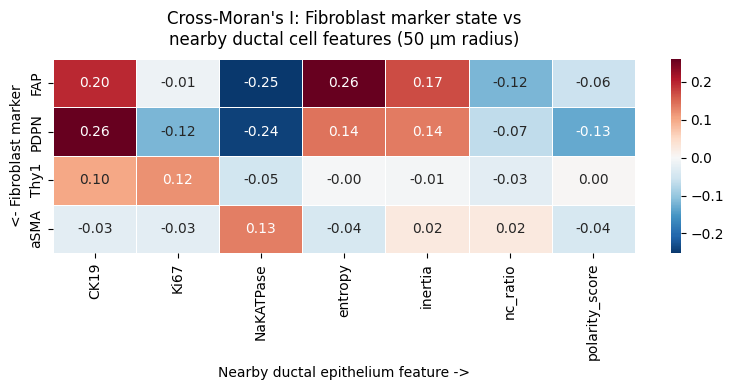

In [32]:
heat_df = matrix_df.pivot(
    index="source_feature", columns="target_feature", values="cross_morans_i"
)

# Clean up axis labels
heat_df.index   = [i.replace("_expr_z", "").replace("_z", "") for i in heat_df.index]
heat_df.columns = [c.replace("_expr_z", "").replace("_z", "") for c in heat_df.columns]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    heat_df, cmap="RdBu_r", center=0, linewidths=0.5,
    annot=True, fmt=".2f", ax=ax,
)
ax.set_title("Cross-Moran's I: Fibroblast marker state vs\nnearby ductal cell features (50 µm radius)", pad=10)
ax.set_xlabel("Nearby ductal epithelium feature ->")
ax.set_ylabel("<- Fibroblast marker")
fig.tight_layout()

**Reading the cross-Moran's I matrix:**

Positive values indicate spatial co-variation — fibroblasts with high expression of row-marker
tend to sit near ductal cells with high value of the column-feature.

**Biologically informative patterns:**
- **FAP x Ki67**: if positive -> activated CAFs concentrate near proliferating tumour cells
  (active invasion front, desmoplastic reaction driven by tumour proliferation)
- **FAP x entropy**: if positive -> FAP-high CAFs are enriched near morphologically complex
  (disorganised) ductal cells — hallmark of the invasive tumour-stroma interface
- **aSMA x nc_ratio**: if positive -> myofibroblastic CAFs associate with ductal cells
  that have high nuclear-to-cell ratio (common in high-grade PDAC)
- **PDPN x polarity_score**: PDPN marks a more inflammatory/lymphangiogenic CAF subset;
  if negative here, these CAFs may be more distal from the proliferative tumour front

Any strongly positive coupling at this 50 µm radius implicates local paracrine signalling
between the two cell types.

In [33]:
# Map where specifically ductal cells with high entropy (morphological disorganisation)
# co-localise with high-FAP fibroblast neighbours -> this defines the active invasion front
adata_duct_local = sv.tl.add_local_cross_morans_i_between_phenotypes(
    adata,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    target_phenotype="Fibroblasts",
    source_feature_key="entropy_z",
    target_feature_key="FAP_expr_z",
    radius=50 / PIXEL_SIZE_UM,
    agg="mean",
    x_key="X_centroid", y_key="Y_centroid", image_key="imageid",
    k=8,
)

neighbor_col = "neighbor_mean__FAP_expr_z"
local_i_col  = next(c for c in adata_duct_local.obs.columns
                    if "local_cross_morans_i" in c and "entropy_z" in c)

adata_duct_local = sv.tl.add_local_cross_morans_i_quadrants(
    adata_duct_local,
    source_value_key="entropy_z",
    target_neighbor_value_key=neighbor_col,
    local_i_key=local_i_col,
)
cross_quad_col = next(c for c in adata_duct_local.obs.columns
                      if "local_cross_morans_quadrant" in c and "entropy" in c)
print("Cross-Moran quadrant counts (ductal cells):")
print(adata_duct_local.obs[cross_quad_col].value_counts())

Cross-Moran quadrant counts (ductal cells):
local_cross_morans_quadrant__entropy_z__neighbor_mean__FAP_expr_z
unclassified    163609
high-high       113734
low-high         61379
low-low          45405
high-low         39631
Name: count, dtype: int64


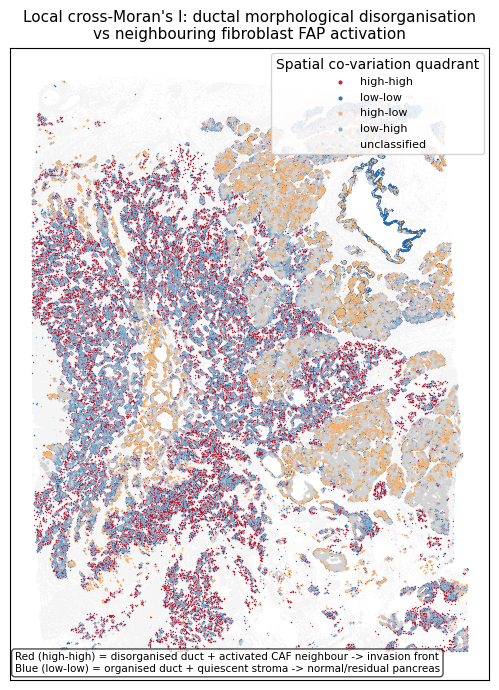

In [34]:
palette = {
    "high-high":    "#b2182b",   # High entropy duct + high FAP neighbours = active invasion front
    "low-low":      "#2166ac",   # Low entropy duct + low FAP neighbours = quiescent / normal region
    "high-low":     "#fdae61",   # Morphologically complex duct without activated stroma
    "low-high":     "#74add1",   # Well-organised duct with activated neighbouring fibroblasts
    "unclassified": "lightgray",
}

quad_vals = adata_duct_local.obs[cross_quad_col].fillna("unclassified")

fig, ax = plt.subplots(figsize=(8, 7))

# All non-ductal cells as background
ax.scatter(
    adata.obs.loc[adata.obs["Tier_A"] != "pancreatic ductal epithelium", "X_centroid"],
    adata.obs.loc[adata.obs["Tier_A"] != "pancreatic ductal epithelium", "Y_centroid"],
    c="whitesmoke", s=0.4, alpha=0.15, linewidths=0, rasterized=True,
)

# Ductal cells coloured by cross-Moran's I quadrant
for quad, color in palette.items():
    sub = adata_duct_local.obs[quad_vals == quad]
    ax.scatter(
        sub["X_centroid"], sub["Y_centroid"],
        c=color, s=1 if quad != "unclassified" else 1,
        alpha=0.9 if quad != "unclassified" else 0.3,
        linewidths=0, label=quad, rasterized=True,
    )

ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(
    "Local cross-Moran's I: ductal morphological disorganisation\nvs neighbouring fibroblast FAP activation",
    fontsize=11,
)
ax.legend(title="Spatial co-variation quadrant", fontsize=8, markerscale=3, loc="upper right")

# Annotation box
ax.text(0.01, 0.01,
        "Red (high-high) = disorganised duct + activated CAF neighbour -> invasion front\n"
        "Blue (low-low) = organised duct + quiescent stroma -> normal/residual pancreas",
        transform=ax.transAxes, fontsize=7.5, va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
fig.tight_layout()

---
## Summary: Spatial organisation of the PDAC TME (sample 34434_1)

This analysis characterised the spatial architecture of a PDAC tissue section at multiple scales:

### 1  Cell type clustering (Ripley's K)
- **Ductal epithelium** clusters strongly at all radii, consistent with compact invasive gland formation
- **B lineage** shows the tightest short-range clustering, supporting tertiary lymphoid structure (TLS) formation at the tumour-immune interface
- **Fibroblasts** cluster at 50-200 µm (stromal compartment scale) but are less condensed at 20 µm — reflecting the desmoplastic sheath rather than direct cell-cell mixing

### 2  Pairwise co-localisation (Cross-Ripley K)
- **Ductal ↔ Fibroblast**: strong positive co-enrichment at 50-200 µm confirms the peri-ductal desmoplastic reaction; the short-range gap at 20 µm reflects the basement membrane separation
- **Ductal ↔ T cells**: the permutation envelope distinguishes immune exclusion vs infiltration — above the 95% envelope indicates T cells are genuinely enriched at tumour margins
- **All-pairs heatmap**: reveals the full spatial wiring of the TME, including which immune subsets co-localise with tumour stroma vs epithelium

### 3  Fibroblast activation state geography (Moran's I)
- FAP expression in fibroblasts is **spatially autocorrelated** (I > 0): activated CAFs are regionally concentrated rather than uniformly distributed
- Local Moran's I identifies **high-high FAP hotspots** (core CAF activation zones near tumour nests) and **low-low coldspots** (quiescent stroma, potentially corresponding to the normal pancreas region)

### 4  Tumour-stroma feature coupling (Cross-Moran's I)
- The cross-Moran's I matrix reveals which aspects of fibroblast activation are spatially correlated with ductal cell behaviour — linking CAF activation markers to tumour proliferation (Ki67) and morphological complexity (entropy)
- **Local cross-Moran's I high-high zones** (high ductal entropy + high neighbouring FAP) mark the **active tumour invasion front** where desmoplastic activation and tumour disorganisation co-occur — potentially the most therapeutically relevant spatial niche in PDAC

**Next steps**: compare these spatial statistics across multiple PDAC samples (experiments 2-5) and across pathological grades using the pseudotime analysis in notebook 06.